In [1]:
# 03_modeling.ipynb
# Purpose: Train baseline ML models to predict concrete compressive strength.

import pandas as pd
import numpy as np

from pathlib import Path

from sklearn.model_selection import GroupKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import make_scorer, mean_absolute_error, r2_score

In [2]:
data_file = Path("../data/concrete_featurized.csv")

df = pd.read_csv(data_file)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (1030, 12)


,cement,slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age,compressive_strength,w_c_ratio,log_age,w_c_ratio_bin
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111,0.300000,3.332205,0
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366,0.300000,3.332205,0
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535,0.685714,5.598422,5
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780,0.685714,5.899897,5
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075,0.966767,5.886104,7


In [3]:
target = "compressive_strength"
group_col = "w_c_ratio_bin"

feature_cols = [
    "cement",
    "slag",
    "fly_ash",
    "water",
    "superplasticizer",
    "coarse_aggregate",
    "fine_aggregate",
    "age",
    "w_c_ratio",
    "log_age"
]

X = df[feature_cols]
y = df[target]
groups = df[group_col]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Number of groups:", groups.nunique())

X shape: (1030, 10)
y shape: (1030,)
Number of groups: 10


In [4]:
cv = GroupKFold(n_splits=5)

scoring = {
    "MAE": "neg_mean_absolute_error",
    "R2": "r2"
}

In [5]:
models = {
    "Ridge": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0))
    ]),
    
    "Lasso": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Lasso(alpha=0.01, max_iter=10000))
    ]),
    
    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=42
    )
}

In [6]:
results = []

for name, model in models.items():
    scores = cross_validate(
        model,
        X,
        y,
        groups=groups,
        cv=cv,
        scoring=scoring,
        return_train_score=False
    )
    
    results.append({
        "model": name,
        "mean_MAE": -scores["test_MAE"].mean(),
        "std_MAE": scores["test_MAE"].std(),
        "mean_R2": scores["test_R2"].mean(),
        "std_R2": scores["test_R2"].std()
    })

results_df = pd.DataFrame(results)
results_df

,model,mean_MAE,std_MAE,mean_R2,std_R2
0,Ridge,5.905440,0.598553,0.727310,0.030692
1,Lasso,5.904012,0.599578,0.727612,0.031100
2,Random Forest,6.135266,2.610374,0.674819,0.257087


In [7]:
feature_cols_no_log = [
    "cement",
    "slag",
    "fly_ash",
    "water",
    "superplasticizer",
    "coarse_aggregate",
    "fine_aggregate",
    "age",
    "w_c_ratio"
]

In [8]:
X_no_log = df[feature_cols_no_log]

models_no_log = {
    "Ridge_no_log_age": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0))
    ]),
    "Random Forest_no_log_age": RandomForestRegressor(
        n_estimators=200,
        random_state=42
    )
}

no_log_results = []

for name, model in models_no_log.items():
    scores = cross_validate(
        model,
        X_no_log,
        y,
        groups=groups,
        cv=cv,
        scoring=scoring,
        return_train_score=False
    )

    no_log_results.append({
        "model": name,
        "mean_MAE": -scores["test_MAE"].mean(),
        "std_MAE": (-scores["test_MAE"]).std(),
        "mean_R2": scores["test_R2"].mean(),
        "std_R2": scores["test_R2"].std()
    })

no_log_results_df = pd.DataFrame(no_log_results)
no_log_results_df

,model,mean_MAE,std_MAE,mean_R2,std_R2
0,Ridge_no_log_age,8.530137,1.371583,0.424635,0.137019
1,Random Forest_no_log_age,6.147062,2.576929,0.674709,0.253907


In [9]:
log_age_comparison = pd.concat([
    no_log_results_df,
    results_df[results_df["model"].isin(["Ridge", "Random Forest"])]
])

log_age_comparison

,model,mean_MAE,std_MAE,mean_R2,std_R2
0,Ridge_no_log_age,8.530137,1.371583,0.424635,0.137019
1,Random Forest_no_log_age,6.147062,2.576929,0.674709,0.253907
0,Ridge,5.905440,0.598553,0.727310,0.030692
2,Random Forest,6.135266,2.610374,0.674819,0.257087


## Log(age) Transformation Interpretation

Adding `log_age` strongly improved the Ridge model. Without `log_age`, Ridge achieved MAE ≈ 8.53 MPa and R² ≈ 0.42. With `log_age`, Ridge improved to MAE ≈ 5.91 MPa and R² ≈ 0.73. Random Forest changed very little, remaining near R² ≈ 0.67. This suggests that much of Random Forest's expected advantage over a linear model came from the nonlinear age-strength relationship, which was captured directly by the engineered `log_age` feature. This is physically meaningful because concrete gains strength rapidly at early ages and more slowly at later ages.

In [10]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X, y)

feature_importance = pd.Series(
    rf.feature_importances_,
    index=feature_cols
).sort_values(ascending=False)

feature_importance

w_c_ratio           0.375122
age                 0.181771
log_age             0.177857
slag                0.082329
superplasticizer    0.042982
cement              0.037055
fine_aggregate      0.034675
water               0.030759
coarse_aggregate    0.023276
fly_ash             0.014175
dtype: float64

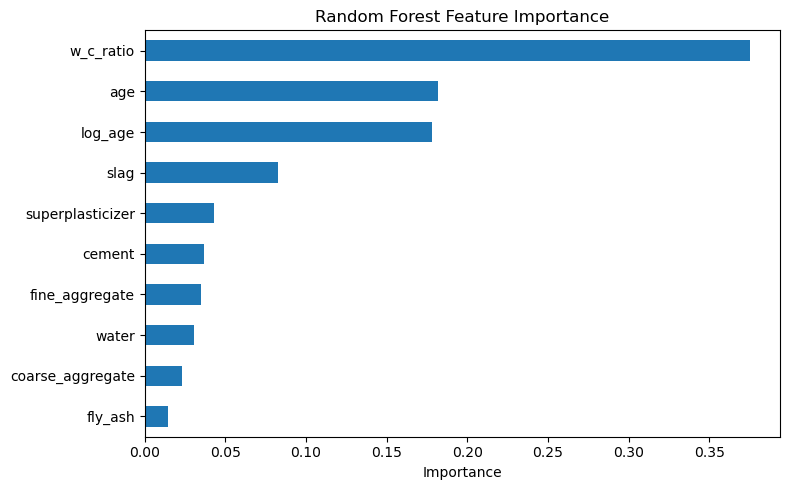

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
feature_importance.sort_values().plot(kind="barh")
plt.xlabel("Importance")
plt.title("Random Forest Feature Importance")
plt.tight_layout()
plt.savefig("../figures/rf_feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

In [12]:
lasso_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Lasso(alpha=0.01, max_iter=10000))
])

lasso_pipeline.fit(X, y)

lasso_coefficients = pd.Series(
    lasso_pipeline.named_steps["model"].coef_,
    index=feature_cols
).sort_values(key=abs, ascending=False)

lasso_coefficients

log_age             12.133152
cement              11.839796
slag                 9.796828
fly_ash              5.574294
fine_aggregate       2.610182
w_c_ratio           -2.467309
age                 -2.407992
water               -2.098797
coarse_aggregate     1.994663
superplasticizer     0.552624
dtype: float64

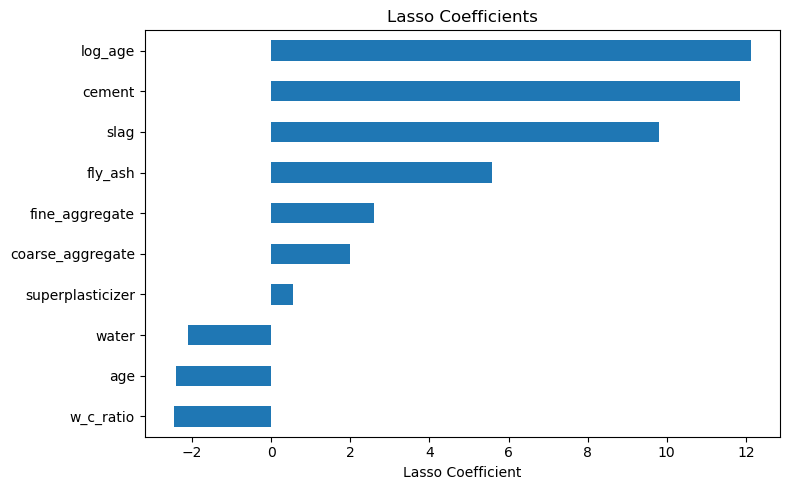

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
lasso_coefficients.sort_values().plot(kind="barh")
plt.xlabel("Lasso Coefficient")
plt.title("Lasso Coefficients")
plt.tight_layout()
plt.savefig("../figures/model_comparison.png", dpi=300)
plt.show()

### Water-Cement Ratio Lasso Interpretation

The engineered `w_c_ratio` feature was computed as `water / cement` and included alongside the raw `water` and `cement` columns. Lasso did not zero out `w_c_ratio`; it retained a negative coefficient, which is physically reasonable because higher water-to-cement ratio generally reduces compressive strength. Lasso also retained the raw `cement` and `water` columns, indicating that the engineered ratio adds useful information but does not completely replace the original mixture variables.

## Modeling Summary

Three regression models (Ridge, Lasso, and Random Forest) were evaluated using 5-fold GroupKFold cross-validation grouped by water-to-cement ratio bins. Lasso achieved the best performance (MAE ≈ 5.90 MPa, R² ≈ 0.73), closely followed by Ridge. Random Forest performed slightly worse under the grouped split.

Testing the `log_age` transformation showed that Ridge improved from R² ≈ 0.42 without `log_age` to R² ≈ 0.73 with `log_age`. This suggests that the logarithmic age feature captured the nonlinear curing-age effect and reduced the expected advantage of Random Forest over linear models.

Random Forest feature importance identified water-to-cement ratio, age, and logarithmic age as the most influential variables. Lasso also retained `w_c_ratio`, `cement`, and `water`, showing that the engineered water-to-cement ratio added useful information without fully replacing the raw columns.